# 09 · PAGA

[Chapter 08](08_cell_type_annotation.ipynb) gave you three named states. It did not give
you any relationship *between* them — a clustering returns groups, and a group has no
neighbours.

If you need more help for this section scanpy has a really good guide explaining this method: here[https://scanpy.readthedocs.io/en/latest/tutorials/trajectories/paga-paul15.html]

But the neighbour graph knows. Two clusters joined by thousands of edges are adjacent in
the data; two joined by none are not, whatever a UMAP puts next to what. **PAGA** —
partition-based graph abstraction — collapses the cell-level graph into a graph *between
clusters*, so that the connectivity you already computed becomes something you can read.

| | |
|---|---|
| **1** | Clusters finer than you would annotate |
| **2** | Abstract the graph |
| **3** | Read an edge |
| **4** | What the topology says |
| **5** | Use it to lay out a UMAP |

:::{note}
Still the controls — every DMSO and PBS cell, no compounds. Whatever shape appears here is
the shape untreated cells make on their own, which is the only baseline against which a
perturbation means anything.
:::

In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

plt.rcParams.update({          # the house style, no package needed
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False,
    "legend.frameon": False, "pdf.fonttype": 42, "ps.fonttype": 42,
})
pd.set_option("display.width", 140)

# The tables live here on Euler. Change this line if your copy is elsewhere.
DATA = Path("/cluster/project/mcsliberali/data_mcs_2026")

cells = sc.read_h5ad(DATA / "mcs2026_controls_downstream.h5ad")
identity = [m for m in cells.uns["panels"]["identity"] if m in set(cells.var_names)]

print(f"{cells.n_obs:,} control cells")
print(f"  states from chapter 08: {list(cells.obs.cell_state.cat.categories)}")
print(f"  graph : {cells.obsp['identity_connectivities'].nnz:,} edges, from chapter 07")

97,177 control cells
  states from chapter 08: ['Pluripotent', 'TE-like', 'Hypoblast', 'artefact']
  graph : 2,553,740 edges, from chapter 07


## 1 · Clusters finer than you would annotate

Chapter 08 settled on resolution 0.1 because three clusters were all it could **name**.
That is the right resolution for an annotation and the wrong one for a topology: three
blobs have three possible edges, and a graph with three nodes tells you almost nothing.

PAGA wants more nodes than you would ever put in a figure legend. The abstraction is what
makes them readable again.

Here we will use cluster resolution 0.3 - to calculate PAGA however, you may even want finer clusters. Finer clusters will reveal better neighbourhood relationships.

In [17]:
for resolution in [0.1, 0.3]:
    sc.tl.leiden(cells, resolution=resolution, key_added=f"leiden_{resolution}",
                 flavor="igraph", n_iterations=2, random_state=0,
                 neighbors_key="identity")
    counts = cells.obs[f"leiden_{resolution}"].value_counts()
    print(f"  resolution {resolution}: {len(counts):2d} clusters, "
          f"smallest {counts.min():,} cells ({counts.min() / cells.n_obs:.2%})")

cells.obs["fine"] = cells.obs["leiden_0.3"]

  resolution 0.1:  4 clusters, smallest 251 cells (0.26%)
  resolution 0.3: 11 clusters, smallest 204 cells (0.21%)


Eleven clusters. Read it before the graph:

In [18]:
profile = (pd.DataFrame(cells.obsm["X_identity"], columns=identity)
           .groupby(cells.obs.fine.astype(str).values, observed=True).mean())
profile.index.name = "cluster"
sizes = cells.obs.fine.value_counts()
profile.round(2).join(sizes.rename("cells"))

,Oct4,Nanog,Sox2,GATA3,GATA6,PDGFRa,GATA4,SOX17,cells
cluster,,,,,,,,,
0,0.22,0.31,0.21,-0.40,-0.47,-0.43,0.01,-0.51,12926
1,-1.21,0.04,-1.37,-0.31,-0.91,-0.80,0.07,-0.03,4156
10,0.11,0.23,-0.08,0.36,0.04,3.39,0.03,-0.10,1117
2,-0.11,-0.07,-0.30,0.33,0.29,-4.84,0.03,0.31,204
3,-1.04,-0.99,-1.38,1.53,-0.34,-0.20,0.04,-0.24,16773
4,-0.93,-0.96,-1.43,-1.20,0.10,0.49,3.09,2.13,9838
5,0.63,0.51,0.29,0.43,1.39,0.86,0.04,0.48,10575
6,-0.80,-0.98,-1.30,0.18,-0.36,-0.25,0.03,1.62,8714
7,0.94,0.92,0.68,0.20,0.40,0.57,0.04,-0.07,26905


Most of these are versions of the three named states — several flavours of pluripotent,
one strongly GATA3, one strongly GATA4/SOX17. One of them is not.

In [19]:
both = profile[(profile[["Oct4", "Nanog", "Sox2"]].mean(axis=1) > 0.3)
               & (profile[["GATA4", "SOX17"]].mean(axis=1) > 0.5)]
print(f"clusters high in pluripotency AND hypoblast markers at once: {list(both.index)}")
both.round(2).join(sizes.rename("cells"))

clusters high in pluripotency AND hypoblast markers at once: ['9']


,Oct4,Nanog,Sox2,GATA3,GATA6,PDGFRa,GATA4,SOX17,cells
cluster,,,,,,,,,
9,0.88,0.83,0.58,0.16,0.66,0.97,1.31,1.43,3813


:::{important}
**A cluster that is high in both.** Oct4, Nanog and Sox2 up — and GATA4 and SOX17 up as
well, in the same cells. Under the three-state annotation these were filed as
`Pluripotent`, because that is the closest of three names, and the co-expression was
invisible.

Co-expression of a starting state and a destination state is what a **transition** looks
like in fixed cells. You cannot watch a cell change in a 4i experiment — every cell is
imaged once — so a cell caught carrying both programmes is as close as the data
comes to showing you the act.

It is also a small minority of the cells, which is why the resolution mattered: at 0.1 it
sits inside a larger cluster and there is nothing to see.
:::

## 2 · Abstract the graph

`sc.tl.paga` takes the cell-level neighbour graph and a partition of it, and returns one
weight per pair of clusters: how connected they are, relative to how connected they would
be if edges were placed at random.

In [20]:
sc.tl.paga(cells, groups="fine", neighbors_key="identity")

connectivity = pd.DataFrame(cells.uns["paga"]["connectivities"].toarray(),
                            index=profile.index, columns=profile.index)
connectivity.round(3)

cluster,0,1,10,2,3,4,5,6,7,8,9
cluster,,,,,,,,,,,
0,0.000,0.097,0.081,0.043,0.000,0.098,0.046,0.137,0.029,0.023,0.070
1,0.097,0.000,0.273,0.149,0.025,0.087,0.213,0.005,0.010,0.036,0.158
10,0.081,0.273,0.000,0.032,0.000,0.000,0.079,0.000,0.000,0.000,0.000
2,0.043,0.149,0.032,0.000,0.014,0.040,0.174,0.000,0.090,0.001,0.082
3,0.000,0.025,0.000,0.014,0.000,0.005,0.054,0.000,0.008,0.039,0.005
4,0.098,0.087,0.000,0.040,0.005,0.000,0.115,0.212,0.167,0.186,0.245
5,0.046,0.213,0.079,0.174,0.054,0.115,0.000,0.000,0.001,0.051,0.092
6,0.137,0.005,0.000,0.000,0.000,0.212,0.000,0.000,0.151,0.130,0.095
7,0.029,0.010,0.000,0.090,0.008,0.167,0.001,0.151,0.000,0.148,0.052


When drawing, the graph we can use a **threshold**, because almost every pair has some connectivity. Section
3 chooses a threshold to cut the possible connectivities; here you can take a value that leaves the graph in one piece, and note
that you had to look at the numbers to find it.

Below you have a function that allows you to check how many edges will be drawn at that threshold and in how many pieces the graph is divided.

In [21]:
def components(matrix, cut):
    """Which clusters remain connected once edges below `cut` are dropped."""
    nodes, seen, groups = list(matrix.index), set(), []
    for start in nodes:
        if start in seen:
            continue
        stack, group = [start], set()
        while stack:
            node = stack.pop()
            if node in group:
                continue
            group.add(node); seen.add(node)
            stack += [m for m in nodes if m != node and matrix.loc[node, m] > cut]
        groups.append(sorted(group))
    return groups

for cut in [0.05, 0.07, 0.10, 0.15]:
    pieces = components(connectivity, cut)
    edges = int((np.triu(connectivity.values, 1) > cut).sum())
    print(f"  threshold {cut:.2f}: {edges:2d} edges, {len(pieces)} component(s)  {pieces}")

THRESHOLD = 0.07

  threshold 0.05: 28 edges, 1 component(s)  [['0', '1', '10', '2', '3', '4', '5', '6', '7', '8', '9']]
  threshold 0.07: 24 edges, 2 component(s)  [['0', '1', '10', '2', '4', '5', '6', '7', '8', '9'], ['3']]
  threshold 0.10: 15 edges, 2 component(s)  [['0', '1', '10', '2', '4', '5', '6', '7', '8', '9'], ['3']]
  threshold 0.15:  9 edges, 3 component(s)  [['0'], ['1', '10', '2', '4', '5', '6', '7', '8', '9'], ['3']]


In this case, we choose 0.07 as the `THRESHOLD`. However, we have now divided the graph in two. 

:::{note}
You can play here with the parameters to achieve a better graph: You can play with using higher resolution clusters and with lower thresholds to include more connectivities.
:::

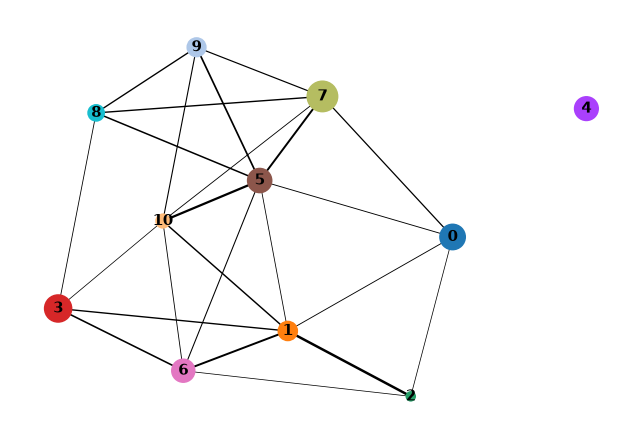

In [22]:
sc.pl.paga(cells, threshold=THRESHOLD, frameon=False, fontsize=10,
           node_size_scale=1.5, edge_width_scale=0.8)

## 3 · Read an edge

The number in that matrix is a **strength** of connectivity, not a fact. Every pair of clusters gets one,
and almost every one of them is greater than zero.

  55 possible edges
    above 0.00: 48 edges
    above 0.01: 39 edges
    above 0.05: 28 edges
    above 0.07: 24 edges
    above 0.10: 15 edges
    above 0.20:  4 edges


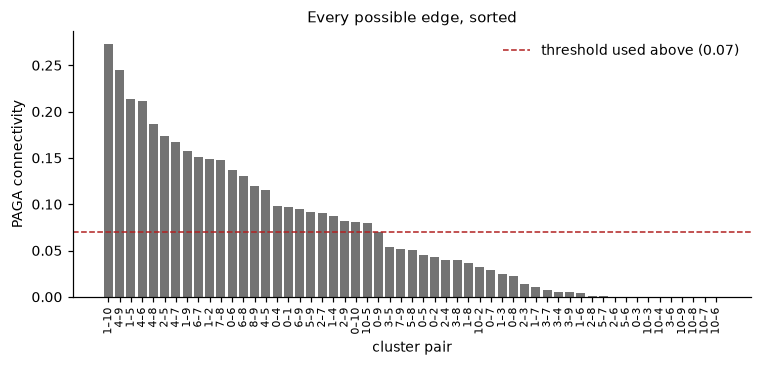

In [23]:
pairs = [(a, b, connectivity.loc[a, b])
         for i, a in enumerate(connectivity.index) for b in connectivity.index[i + 1:]]
weights = pd.Series({f"{a}–{b}": w for a, b, w in pairs}).sort_values(ascending=False)

print(f"  {len(pairs)} possible edges")
for cut in [0.0, 0.01, 0.05, 0.07, 0.10, 0.20]:
    print(f"    above {cut:.2f}: {(weights > cut).sum():2d} edges")

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(range(len(weights)), weights.values, color="0.45")
ax.axhline(THRESHOLD, color="firebrick", ls="--", lw=1, label=f"threshold used above ({THRESHOLD})")
ax.set(xticks=range(len(weights)), xlabel="cluster pair", ylabel="PAGA connectivity",
       title="Every possible edge, sorted")
ax.set_xticklabels(weights.index, rotation=90, fontsize=7)
ax.legend()
fig.tight_layout()

:::{warning}
**The threshold is a choice, and here it is doing more work than anywhere else in the
course.** Drop it to 0.01 and the graph is nearly complete — every state connected to every
other, which is true and useless. Raise it to 0.15 and the component listing above shows
the graph breaking into three pieces, with the hypoblast cluster **alone**.

Look at where its edges actually fall.

There is no correct value. What is required is that you **say which one you used**, and
that the claim survives a reasonable change to it. A valid option is also to choose no threshold and present all edges.
:::

## 4 · Use it to lay out a UMAP

A UMAP starts from a random initialisation, which is why chapter 07's two runs came out
rearranged. Starting it from the PAGA layout instead makes the global arrangement
reproducible and roughly meaningful, because it inherits a structure that *was* computed
from connectivity.

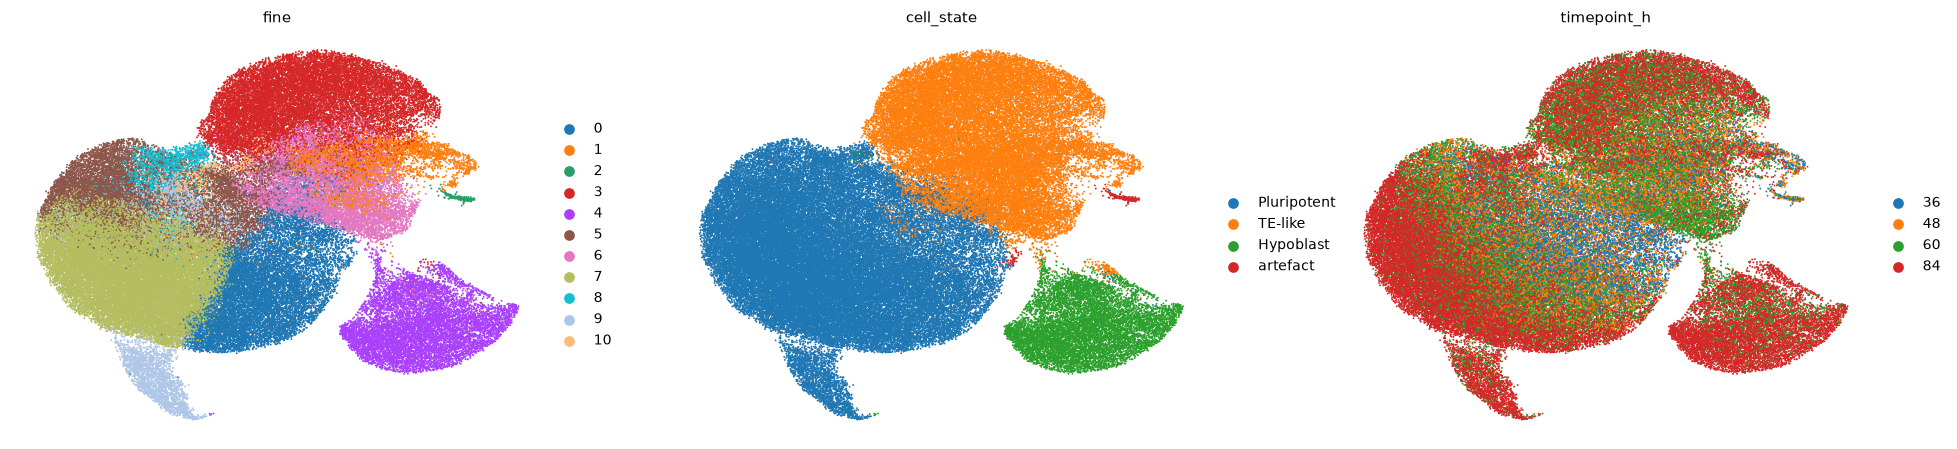

In [28]:
sc.tl.paga(cells, groups="fine", neighbors_key="identity")   # the graph the UMAP uses
sc.pl.paga(cells, plot=False)             # computes uns['paga']['pos'] -- required below
sc.tl.umap(cells, init_pos="paga", random_state=0, neighbors_key="identity")

sc.pl.umap(cells, color=["fine", "cell_state", "timepoint_h"],
           ncols=3, s=6, frameon=False)

### The same graph, force-directed

`sc.tl.draw_graph` starts from those same PAGA positions but keeps going: connected
cells pull together, everything else pushes apart, and the layout settles where those
forces balance. It spreads out trajectories that UMAP packs into blobs, which is why it
is the usual companion to a PAGA graph. The same caveat applies though — the distance
between two clusters that ended up far apart still means nothing.


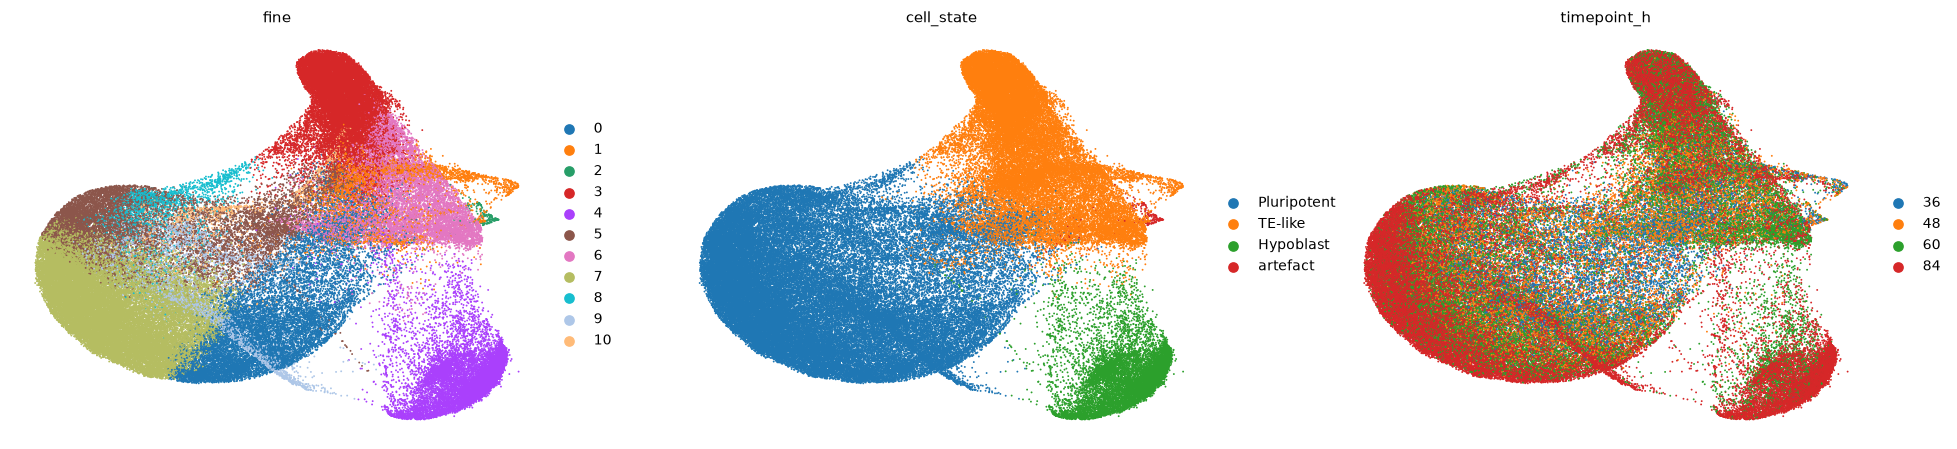

In [33]:
sc.tl.draw_graph(cells, init_pos="paga", neighbors_key="identity", maxiter=150)

sc.pl.draw_graph(cells, color=["fine", "cell_state", "timepoint_h"],
                 ncols=3, s=6, frameon=False)

:::{note}
**`sc.pl.paga` must run before `sc.tl.umap(init_pos="paga")`.** The layout positions are
computed by the *plotting* function, not the tool, and scanpy will otherwise stop with
`Plot PAGA first, so that adata.uns['paga']['pos'] exists`. Passing `plot=False` computes
them without drawing anything.

This is a real trap and not a deep one: an initialisation is not a result, and a
PAGA-initialised UMAP is no more true than a random one. It is more *reproducible*, which
is a different and smaller virtue.
:::

## Save

In [34]:
cells.write_h5ad(DATA / "mcs2026_controls_downstream.h5ad", compression="gzip")
print(f"  obs : fine ({cells.obs.fine.nunique()} clusters), cell_state")
print(f"  obsm: {list(cells.obsm)}")
print(f"  uns : paga connectivities for {len(connectivity)} clusters")

  obs : fine (11 clusters), cell_state
  obsm: ['X_identity', 'X_pca', 'X_pca_full', 'X_umap', 'X_umap_fullintensity', 'X_umap_identity', 'X_draw_graph_fa']
  uns : paga connectivities for 11 clusters


---

## Summary

### 1. What is PAGA?

**Partition-based graph abstraction** takes the neighbour graph you already have and
coarse-grains it by a partition of the cells — here, the Leiden clusters. What comes out is
one node per cluster and, between them, an edge weight that scanpy calls *confidence in the
presence of a connection*.

That number is worth pinning down, because it is the easiest thing in the chapter to
over-read. It is the **ratio of the connections actually seen between two clusters to the
number expected** if the same cells had been wired up at random. Well above 1 means two
clusters touch more than chance would give you; near 0 means they barely touch. There is
deliberately **no p-value**: scanpy's own documentation notes that this null model
overestimates the expected value badly enough that a p-value from it would mislead.

So PAGA does not tell you your clusters are right. It tells you how strongly they touch,
*given the graph you built* — which is why the sections above spend their time on the graph
and on the threshold rather than on the picture.

### 2. Steps to calculate PAGA

1. **A neighbour graph** — `sc.pp.neighbors()`, usually computed on a PCA
   (`sc.pp.pca()`) so that distances are taken in a few informative dimensions.
2. **A partition of it** — `sc.tl.leiden()`, or `sc.tl.louvain()`, deliberately finer than
   you would annotate by hand.
3. **The abstraction** — `sc.tl.paga()`. The only step that actually computes PAGA; it
   writes the cluster-by-cluster matrix into `uns["paga"]["connectivities"]`.
4. **Draw it** — `sc.pl.paga()`. It plots the graph, applies `threshold=` to hide weak
   edges, and as a side effect computes the node positions in `uns["paga"]["pos"]`.
5. **Optionally, re-lay out the cells** — `sc.tl.umap(init_pos="paga")` or
   `sc.tl.draw_graph(init_pos="paga")`, then `sc.pl.umap()` / `sc.pl.draw_graph()`.

:::{note}
**Steps 1 and 2 happened before this chapter.** [Chapter 07](07_umap.ipynb) built the
neighbour graph on the eight identity markers, with `use_rep="X_identity"` rather than on a
PCA, and [chapter 08](08_cell_type_annotation.ipynb) clustered it. Nothing here touches PCA
— we start at step 3.
:::

### 3. Ways of representing PAGA

| | |
|---|---|
| `sc.pl.paga` | The abstracted graph itself: one node per cluster, edge width by connectivity, `threshold` hiding the weak ones. |
| `sc.pl.paga_compare` | The same graph side by side with the single-cell embedding, under one colouring. |
| `sc.pl.paga_path` | A heatmap of chosen markers along a path of clusters — how they change as you walk a branch. |
| `sc.pl.paga_adjacency` | The connectivity matrix drawn as an image. |
| `init_pos="paga"` | Not a picture of PAGA at all: an ordinary UMAP or force-directed layout of the cells, whose *global* arrangement is inherited from the abstracted graph. |

You can also just read the matrix. `cells.uns["paga"]["connectivities"]` is a sparse
cluster x cluster array — which is exactly what section 2 above turns into a `DataFrame`.

Two practical notes on `sc.pl.paga_path`: it annotates with `dpt_pseudotime` by default, so
it needs the pseudotime that [chapter 10](10_diffusion_map.ipynb) computes; and it needs
`use_raw=False` on this object, because the measured values live in `layers["raw"]` rather
than in `.raw`.

### 4. Ways of calculating PAGA

A PAGA graph is *entirely* determined by two choices made before `sc.tl.paga` ever runs —
**what the neighbour graph was built on**, and **which partition you hand it**. Change
either and the same cells give you a different topology:

- **The representation.** A PCA is the default. A **diffusion map** is the quieter option:
  computing distances in a few diffusion components, as scanpy's guide puts it, "amounts to
  denoising the graph – we just take a few of the first spectral components. It's very
  similar to denoising a data matrix using PCA." Or a chosen marker panel, as here.
- **`n_neighbors`.** More neighbours means a smoother graph, more edges, and fewer separate
  components.
- **The partition.** Leiden or Louvain, and at which resolution. A finer partition gives
  more nodes and a more detailed, noisier abstraction.

:::{important}
Scanpy's guide is explicit that the diffusion-map step is optional: "This is *not* a
necessary step, neither for PAGA, nor clustering, nor pseudotime estimation." Treat it as
one graph among several rather than as the correct one.
:::

`threshold` belongs to none of these. It changes the picture at plotting time and leaves the
numbers in `uns["paga"]` untouched, which is why section 3 could sweep it without
recomputing anything.

---

**Next:** [10 · Diffusion maps](10_diffusion_map.ipynb).